<a href="https://colab.research.google.com/github/habibasati018-debug/COFFEE-SALES-ANALYSIS-/blob/main/COFFEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **IMPORTING LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


importing data

In [ ]:
coffee_sales = pd.read_csv('/content/COFFEE STOCK.csv')
coffee_sales

,date,datetime,cash_type,card,money,coffee_name
0,3/1/2024,15:50.5,card,ANON-0000-0000-0001,38.70,Latte
1,3/1/2024,19:22.5,card,ANON-0000-0000-0002,38.70,Hot Chocolate
2,3/1/2024,20:18.1,card,ANON-0000-0000-0002,38.70,Hot Chocolate
3,3/1/2024,46:33.0,card,ANON-0000-0000-0003,28.90,Americano
4,3/1/2024,48:14.6,card,ANON-0000-0000-0004,38.70,Latte
...,...,...,...,...,...,...
1128,7/31/2024,53:35.1,card,ANON-0000-0000-0443,23.02,Cortado
1129,7/31/2024,59:25.0,card,ANON-0000-0000-0040,27.92,Americano with Milk
1130,7/31/2024,26:26.0,card,ANON-0000-0000-0444,32.82,Latte
1131,7/31/2024,54:11.8,card,ANON-0000-0000-0445,32.82,Latte


EXPLORATRY DATA ANALYSIS(EDA)

In [ ]:
print(coffee_sales.head())

       date datetime cash_type                 card  money    coffee_name
0  3/1/2024  15:50.5      card  ANON-0000-0000-0001   38.7          Latte
1  3/1/2024  19:22.5      card  ANON-0000-0000-0002   38.7  Hot Chocolate
2  3/1/2024  20:18.1      card  ANON-0000-0000-0002   38.7  Hot Chocolate
3  3/1/2024  46:33.0      card  ANON-0000-0000-0003   28.9      Americano
4  3/1/2024  48:14.6      card  ANON-0000-0000-0004   38.7          Latte


In [ ]:
coffee_sales.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='object')

In [ ]:
coffee_sales.index

RangeIndex(start=0, stop=1133, step=1)

In [ ]:
coffee_sales.shape

(1133, 6)

In [ ]:
coffee_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


In [ ]:
coffee_sales.cash_type.unique()

array(['card', 'cash'], dtype=object)

In [ ]:
coffee_sales.card= coffee_sales.card.fillna('-')

In [ ]:
coffee_sales.coffee_name.nunique()

8

In [ ]:
import datetime
coffee_sales.rename(mapper={'cash_type':'payment_mode','card':'card_no.'},axis='columns',inplace=True)
coffee_sales.insert(2, 'time', pd.to_datetime(coffee_sales['datetime'], errors='coerce').dt.time)

/tmp/ipython-input-2302082626.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  coffee_sales.insert(2, 'time', pd.to_datetime(coffee_sales['datetime'], errors='coerce').dt.time)


In [ ]:
coffee_sales.sample(3)

,date,datetime,time,payment_mode,card_no.,money,coffee_name
164,3/24/2024,03:56.0,03:56:00,cash,-,40.00,Latte
209,4/1/2024,15:43.8,15:43:48,card,ANON-0000-0000-0009,33.80,Americano with Milk
737,6/9/2024,30:04.5,NaT,card,ANON-0000-0000-0272,37.72,Latte


CREATING SCATTER PLOT OF SALES VS PREPRATION DURATION

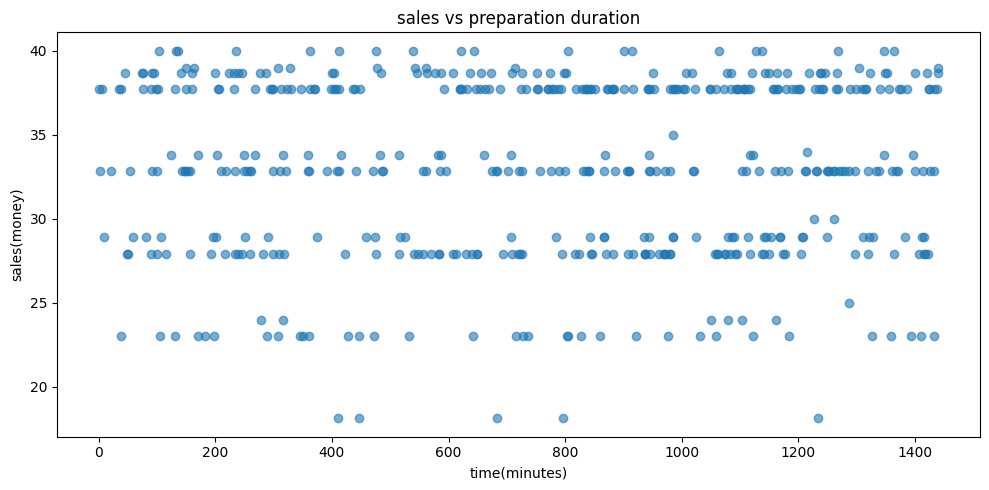

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
coffee_sales.columns = coffee_sales.columns.str.strip()
coffee_sales["time"] = coffee_sales["time"].astype(str)
coffee_sales["time"]=pd.to_timedelta(coffee_sales["time"],errors="coerce")
coffee_sales["minutes"]= coffee_sales["time"].dt.total_seconds()/60
coffee_sales= coffee_sales.dropna(subset=["minutes"])
plt.figure(figsize=(10,5))
plt.scatter(coffee_sales["minutes"], coffee_sales["money"],alpha=0.6)
plt.xlabel("time(minutes)")
plt.ylabel("sales(money)")
plt.title("sales vs preparation duration")
plt.tight_layout()
plt.show()

CREATING LINE CHART FOR VARIATION OF PRICE,SALES AND REVENUE

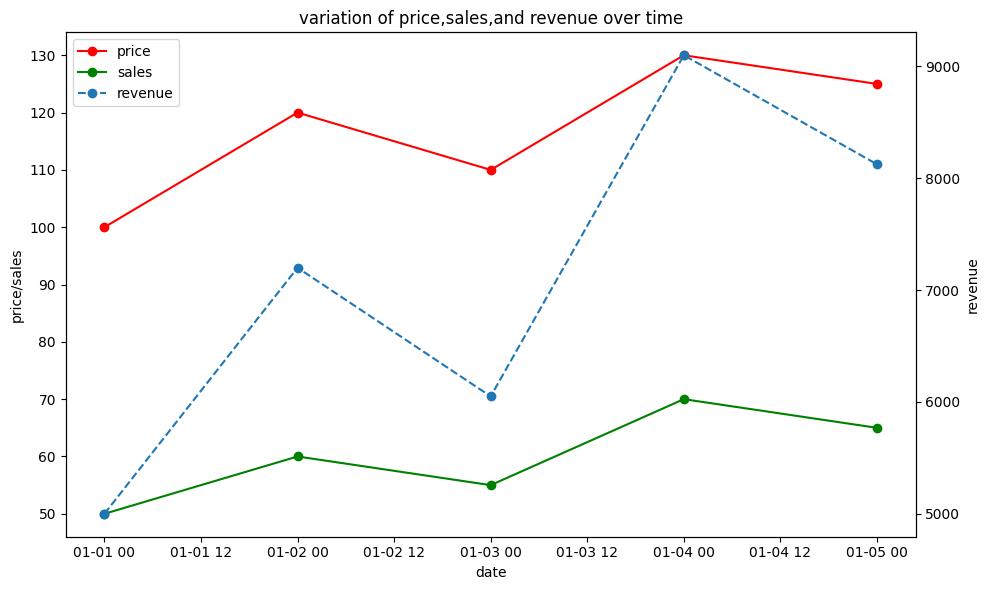

In [ ]:
from matplotlib.lines import lineStyles
data={
    'date':['2024-01-01','2024-01-02','2024-01-03','2024-01-04','2024-01-05'],
    'price':[100,120,110,130,125],
    'sales':[50,60,55,70,65]
    }
coffee_sales=pd.DataFrame(data)
coffee_sales['date']=pd.to_datetime(coffee_sales['date'])
coffee_sales['revenue']=coffee_sales['price']*coffee_sales['sales']
fig,ax1 = plt.subplots(figsize=(10,6))

ax1.plot(coffee_sales['date'],coffee_sales['price'],marker='o',label='price', color='red')
ax1.plot(coffee_sales['date'],coffee_sales['sales'],marker='o',label='sales',color='green')
ax1.set_xlabel('date')
ax1.set_ylabel('price/sales')
ax1.tick_params(axis='y')

ax2=ax1.twinx()
ax2.plot(coffee_sales['date'],coffee_sales['revenue'],marker='o',linestyle='--',label='revenue')
ax2.set_ylabel('revenue')

plt.title("variation of price,sales,and revenue over time")

line1,labels1 = ax1.get_legend_handles_labels()
line2,labels2 = ax2.get_legend_handles_labels()
ax1.legend(line1+line2,labels1+labels2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CREATING DONUT CHART FOR REVENUE COFFE DISTRIBUTION

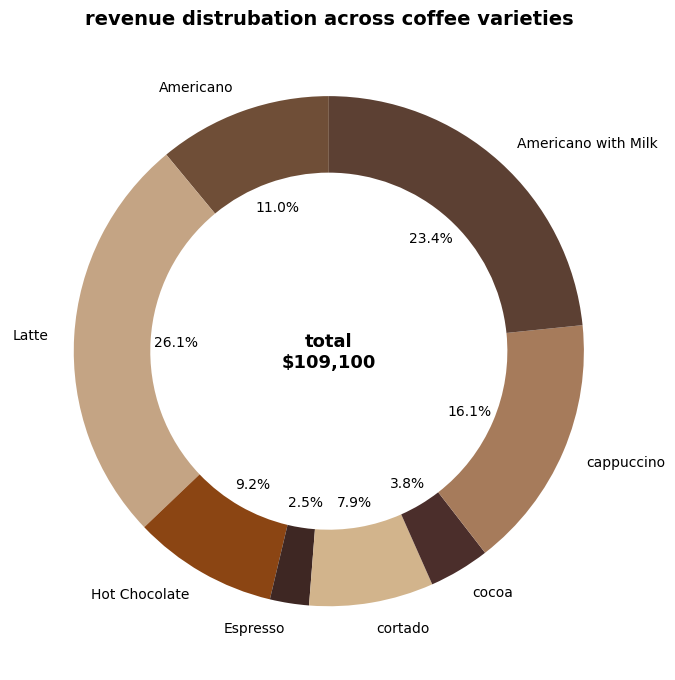

In [ ]:
import matplotlib.pyplot as plt

labels = [
    'Americano',
    'Latte',
    'Hot Chocolate',
    'Espresso',
    'cortado',
    'cocoa',
    'cappuccino',
    'Americano with Milk']

revenue = [12000,28500,10000,2700,8600,4200,17600,25500]
colors  = [
  '#6f4e37',
  '#c4a484',
  '#8b4513',
  '#3e2723',
  '#d2b48c',
  '#4b2e2b',
  '#a67b5b',
  '#5c4033']
# The line below caused the error and is not needed as 'revenue' is already defined.
# revenue_data=coffee_sales.groupby("coffee_name")["money"].sum()
plt.figure(figsize=(7,8))
wedges,texts,autotexts= plt.pie( revenue,
        labels=labels,
        colors=colors[:len(revenue)],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.3))

total= sum(revenue)
plt.text(0,0,f'total\n${total:,.0f}',
         ha='center',va='center',
         fontsize=13, fontweight='bold')

plt.title('revenue distrubation across coffee varieties',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

CREATING BAR PLOT OF SALES BY WEEKDAYS

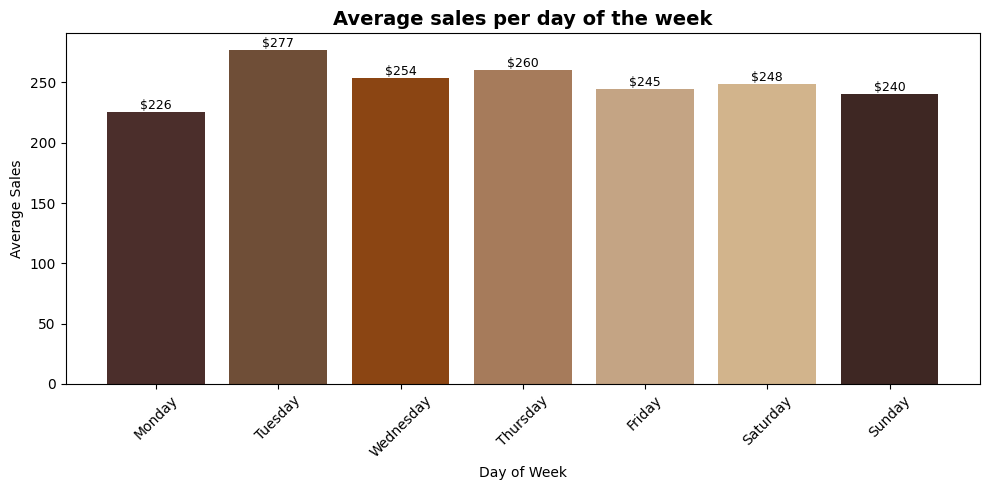

In [ ]:
# Re-load the original coffee_sales DataFrame to ensure 'money' column exists for this plot
df_coffee_sales_original = pd.read_csv('/content/COFFEE STOCK.csv')

# Convert 'date' column to datetime format
df_coffee_sales_original['date'] = pd.to_datetime(df_coffee_sales_original['date'], format='%m/%d/%Y')

daily_sales = df_coffee_sales_original.groupby('date')['money'].sum().reset_index()
daily_sales['day_of_week'] = daily_sales['date'].dt.day_name()

avg_sales = daily_sales.groupby('day_of_week')['money'].mean()

# Corrected capitalization for reindex to match .dt.day_name() output
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_sales = avg_sales.reindex(days_order)
coffee_colors  = [
  '#4B2E2B',
  '#6F4E37',
  '#8B4513',
  '#A67B5B',
  '#C4A484',
  '#D2B48C',
  '#3E2723',
  '#c4a484']

plt.figure(figsize=(10,5))
bar = plt.bar(avg_sales.index,avg_sales.values, color = coffee_colors)
plt.title("Average sales per day of the week", fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)

for bar in bar:
  height = bar.get_height()
  plt.text(bar.get_x()+ bar.get_width()/2,
           height,
           f'${height:,.0f}',
           ha='center', va='bottom',
           fontsize=9)
plt.tight_layout()
plt.show()